In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv('../data/housing.csv')
df.head()

,Unnamed: 0,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,0,7129300520,20141013T000000,221900.0,3.0,1.00,1180,5650,1.0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,1,6414100192,20141209T000000,538000.0,3.0,2.25,2570,7242,2.0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,2,5631500400,20150225T000000,180000.0,2.0,1.00,770,10000,1.0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,3,2487200875,20141209T000000,604000.0,4.0,3.00,1960,5000,1.0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,4,1954400510,20150218T000000,510000.0,3.0,2.00,1680,8080,1.0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [ ]:
df = df.drop(columns=["Unnamed: 0", "id"])

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 22 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Unnamed: 0     21613 non-null  int64  
 1   id             21613 non-null  int64  
 2   date           21613 non-null  str    
 3   price          21613 non-null  float64
 4   bedrooms       21600 non-null  float64
 5   bathrooms      21603 non-null  float64
 6   sqft_living    21613 non-null  int64  
 7   sqft_lot       21613 non-null  int64  
 8   floors         21613 non-null  float64
 9   waterfront     21613 non-null  int64  
 10  view           21613 non-null  int64  
 11  condition      21613 non-null  int64  
 12  grade          21613 non-null  int64  
 13  sqft_above     21613 non-null  int64  
 14  sqft_basement  21613 non-null  int64  
 15  yr_built       21613 non-null  int64  
 16  yr_renovated   21613 non-null  int64  
 17  zipcode        21613 non-null  int64  
 18  lat            21

In [7]:
df["price"].describe()

count    2.161300e+04
mean     5.400881e+05
std      3.671272e+05
min      7.500000e+04
25%      3.219500e+05
50%      4.500000e+05
75%      6.450000e+05
max      7.700000e+06
Name: price, dtype: float64

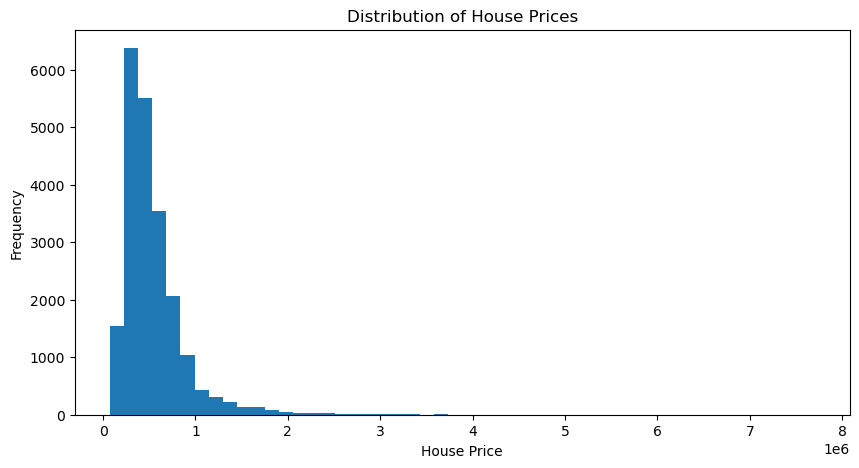

In [8]:
df["price"].plot(kind="hist", bins=50, figsize=(10, 5))
plt.xlabel("House Price")
plt.title("Distribution of House Prices")
plt.show()

In [9]:
df["price"].describe()

count    2.161300e+04
mean     5.400881e+05
std      3.671272e+05
min      7.500000e+04
25%      3.219500e+05
50%      4.500000e+05
75%      6.450000e+05
max      7.700000e+06
Name: price, dtype: float64

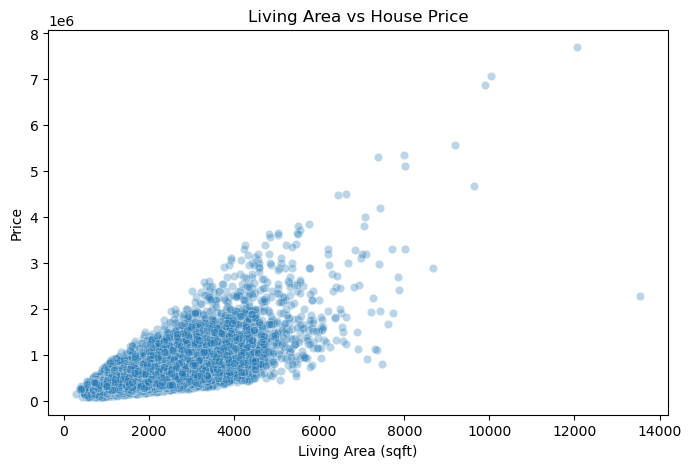

In [10]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="sqft_living",
    y="price",
    alpha=0.3
)

plt.title("Living Area vs House Price")
plt.xlabel("Living Area (sqft)")
plt.ylabel("Price")
plt.show()

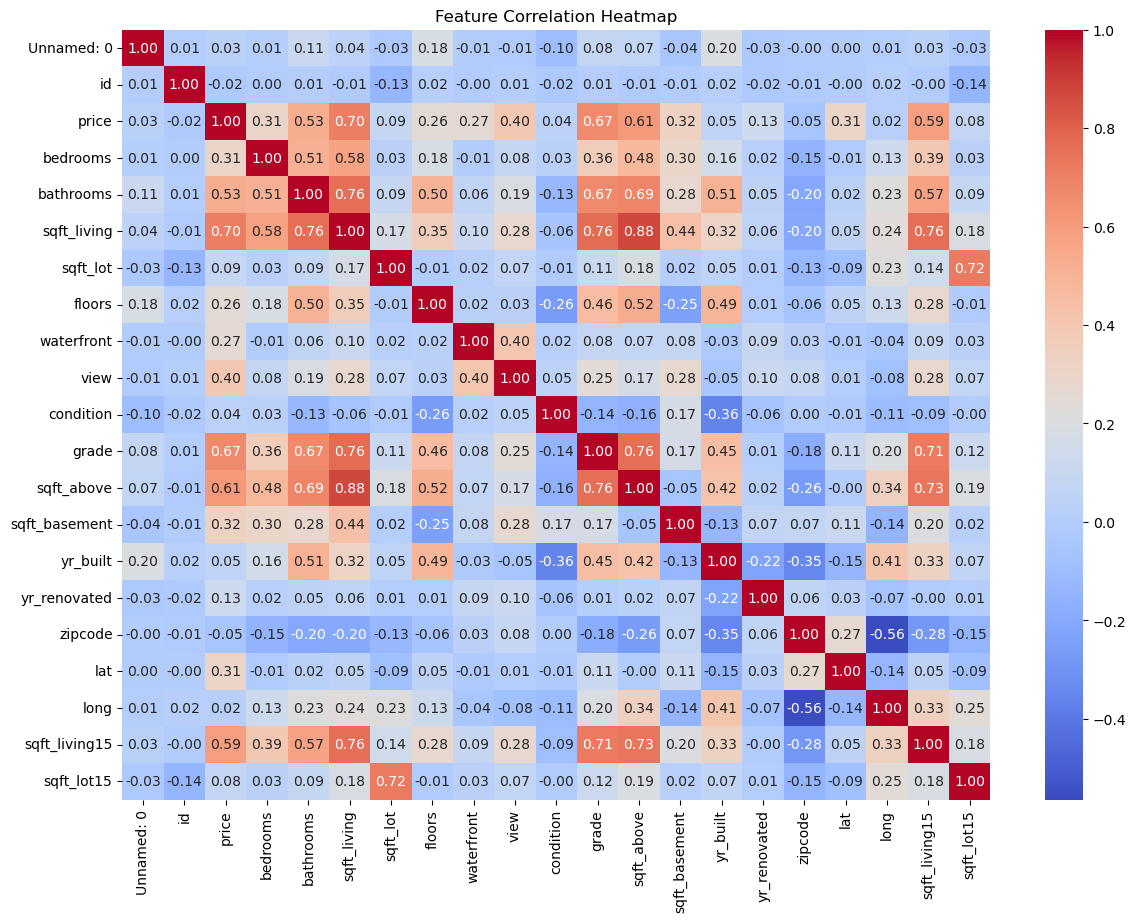

In [11]:
corr = df.select_dtypes(include="number").corr()

plt.figure(figsize=(14, 10))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Feature Correlation Heatmap")
plt.show()

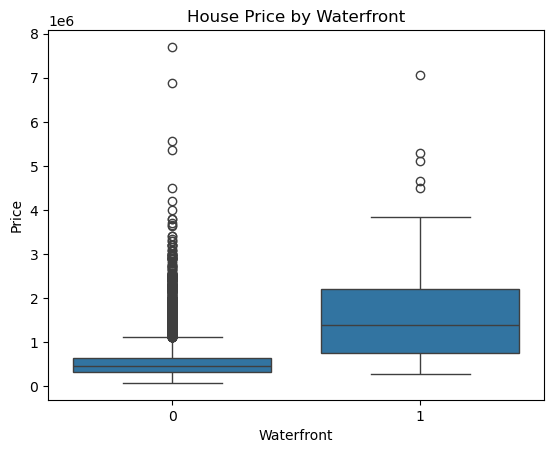

In [12]:
sns.boxplot(
    data=df,
    x="waterfront",
    y="price"
)

plt.title("House Price by Waterfront")
plt.xlabel("Waterfront")
plt.ylabel("Price")
plt.show()

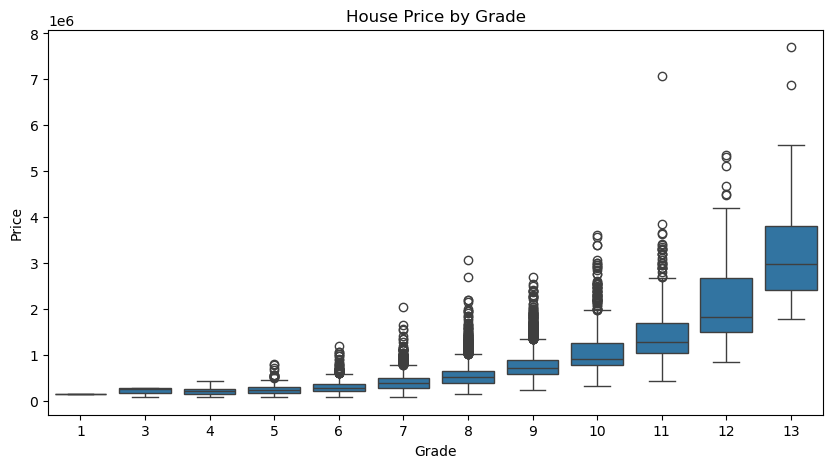

In [13]:
plt.figure(figsize=(10, 5))

sns.boxplot(
    data=df,
    x="grade",
    y="price"
)

plt.title("House Price by Grade")
plt.xlabel("Grade")
plt.ylabel("Price")
plt.show()

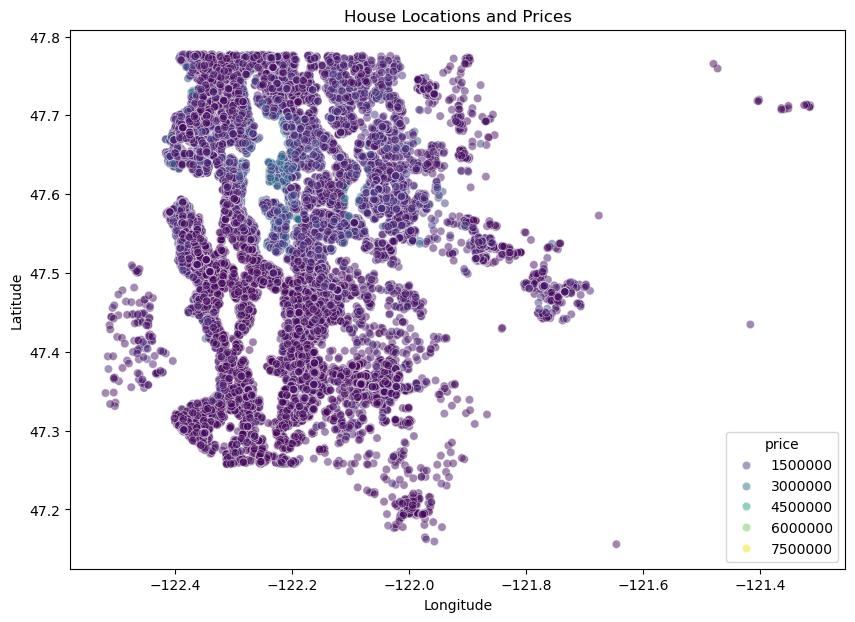

In [14]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=df,
    x="long",
    y="lat",
    hue="price",
    palette="viridis",
    alpha=0.5
)

plt.title("House Locations and Prices")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

In [15]:
df[["lat", "long", "price"]].corr()

,lat,long,price
lat,1.000000,-0.135512,0.307003
long,-0.135512,1.000000,0.021626
price,0.307003,0.021626,1.000000


In [16]:
df.isnull().sum()   

Unnamed: 0        0
id                0
date              0
price             0
bedrooms         13
bathrooms        10
sqft_living       0
sqft_lot          0
floors            0
waterfront        0
view              0
condition         0
grade             0
sqft_above        0
sqft_basement     0
yr_built          0
yr_renovated      0
zipcode           0
lat               0
long              0
sqft_living15     0
sqft_lot15        0
dtype: int64

In [17]:
df[df["bedrooms"].isna() | df["bathrooms"].isna()]

,Unnamed: 0,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
875,875,6306400140,20140612T000000,1095000.0,NaN,NaN,3064,4764,3.5,0,...,7,3064,0,1990,0,98102,47.6362,-122.322,2360,4000
1149,1149,3421079032,20150217T000000,75000.0,1.0,NaN,670,43377,1.0,0,...,3,670,0,1966,0,98022,47.2638,-121.906,1160,42882
3119,3119,3918400017,20150205T000000,380000.0,NaN,NaN,1470,979,3.0,0,...,8,1470,0,2006,0,98133,47.7145,-122.356,1470,1399
3467,3467,1453602309,20140805T000000,288000.0,NaN,1.50,1430,1650,3.0,0,...,7,1430,0,1999,0,98125,47.7222,-122.290,1430,1650
4868,4868,6896300380,20141002T000000,228000.0,NaN,1.00,390,5900,1.0,0,...,4,390,0,1953,0,98118,47.5260,-122.261,2170,6000
5832,5832,5702500050,20141104T000000,280000.0,1.0,NaN,600,24501,1.0,0,...,3,600,0,1950,0,98045,47.5316,-121.749,990,22549
6994,6994,2954400190,20140624T000000,1295650.0,NaN,NaN,4810,28008,2.0,0,...,12,4810,0,1990,0,98053,47.6642,-122.069,4740,35061
8477,8477,2569500210,20141117T000000,339950.0,NaN,2.50,2290,8319,2.0,0,...,8,2290,0,1985,0,98042,47.3473,-122.151,2500,8751
8484,8484,2310060040,20140925T000000,240000.0,NaN,2.50,1810,5669,2.0,0,...,7,1810,0,2003,0,98038,47.3493,-122.053,1810,5685
9773,9773,3374500520,20150429T000000,355000.0,NaN,NaN,2460,8049,2.0,0,...,8,2460,0,1990,0,98031,47.4095,-122.168,2520,8050


In [20]:
df = df.dropna()

In [21]:
df.isnull().sum()

date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long             0
sqft_living15    0
sqft_lot15       0
dtype: int64

In [22]:
df["date"] = pd.to_datetime(df["date"])

In [23]:
df["date"].dtype

dtype('<M8[us]')

In [24]:
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month

In [25]:
df = df.drop(columns=["date"])

In [26]:
df.head()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,...,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,year,month
0,221900.0,3.0,1.00,1180,5650,1.0,0,0,3,7,...,0,1955,0,98178,47.5112,-122.257,1340,5650,2014,10
1,538000.0,3.0,2.25,2570,7242,2.0,0,0,3,7,...,400,1951,1991,98125,47.7210,-122.319,1690,7639,2014,12
2,180000.0,2.0,1.00,770,10000,1.0,0,0,3,6,...,0,1933,0,98028,47.7379,-122.233,2720,8062,2015,2
3,604000.0,4.0,3.00,1960,5000,1.0,0,0,5,7,...,910,1965,0,98136,47.5208,-122.393,1360,5000,2014,12
4,510000.0,3.0,2.00,1680,8080,1.0,0,0,3,8,...,0,1987,0,98074,47.6168,-122.045,1800,7503,2015,2


In [28]:
df.shape

(21597, 21)

In [29]:
X = df.drop(columns=["price"])
y = df["price"]

In [31]:
X.shape

(21597, 20)

In [32]:
y.shape

(21597,)

In [33]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [34]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(17277, 20)
(4320, 20)
(17277,)
(4320,)


In [37]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)

In [38]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 125390.37579391478
RMSE: 199862.7473127565
R²: 0.6929523670251313


In [41]:
coefficients = pd.Series(
    pipeline.named_steps["model"].coef_,
    index=X.columns
).sort_values(ascending=False)

coefficientscoefficients = pd.Series(
    pipeline.named_steps["model"].coef_,
    index=X.columns
).sort_values(ascending=False)

coefficients.sort_values()

yr_built         -78648.161308
bedrooms         -34884.991835
zipcode          -30145.403105
long             -29490.924994
sqft_lot15       -12115.080905
sqft_lot           4058.898366
month              4434.591390
floors             4861.996112
yr_renovated       8266.703414
sqft_living15     16751.904555
year              17720.627528
condition         19527.804080
sqft_basement     28302.715582
bathrooms         32402.561415
view              39336.289701
waterfront        50488.232828
sqft_above        75255.044466
sqft_living       81431.093172
lat               81963.407279
grade            115576.952690
dtype: float64

In [42]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

In [43]:
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = mean_squared_error(y_test, rf_pred) ** 0.5
rf_r2 = r2_score(y_test, rf_pred)

print("MAE:", rf_mae)
print("RMSE:", rf_rmse)
print("R²:", rf_r2)

MAE: 67289.32610027006
RMSE: 124891.13616654296
R²: 0.8801038380477769


In [44]:
feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

feature_importance

grade            0.307129
sqft_living      0.274433
lat              0.159502
long             0.068930
waterfront       0.032583
sqft_living15    0.030941
yr_built         0.025507
sqft_above       0.022294
sqft_lot         0.013488
sqft_lot15       0.012524
zipcode          0.011901
bathrooms        0.009542
view             0.009088
month            0.006100
sqft_basement    0.005742
condition        0.003016
bedrooms         0.002655
floors           0.001747
yr_renovated     0.001707
year             0.001168
dtype: float64

In [45]:
train_pred = rf_model.predict(X_train)

train_r2 = r2_score(y_train, train_pred)
test_r2 = r2_score(y_test, rf_pred)

print("Train R²:", train_r2)
print("Test R²:", test_r2)

Train R²: 0.9830735032073293
Test R²: 0.8801038380477769


In [47]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    "n_estimators": [100, 200, 300, 400],
    "max_depth": [None, 10, 20, 30, 40],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": [1.0, "sqrt", "log2"]
}

random_search = RandomizedSearchCV(
    estimator=RandomForestRegressor(
        random_state=42,
        n_jobs=-1
    ),
    param_distributions=param_grid,
    n_iter=20,
    cv=4,
    scoring="r2",
    random_state=42,
    n_jobs=-1,
    verbose=1
)

In [48]:
random_search.fit(X_train, y_train)

Fitting 4 folds for each of 20 candidates, totalling 80 fits


,estimator,RandomForestR...ndom_state=42)
,param_distributions,"{'max_depth': [None, 10, ...], 'max_features': [1.0, 'sqrt', ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,n_iter,20
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,4
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [49]:
print(random_search.best_params_)

{'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 1.0, 'max_depth': None}


In [50]:
print("Best CV R²:", random_search.best_score_)

Best CV R²: 0.8677008980978973


In [52]:
best_rf = random_search.best_estimator_

In [53]:
tuned_pred = best_rf.predict(X_test)

In [54]:
tuned_mae = mean_absolute_error(y_test, tuned_pred)
tuned_rmse = mean_squared_error(y_test, tuned_pred) ** 0.5
tuned_r2 = r2_score(y_test, tuned_pred)

print("MAE:", tuned_mae)
print("RMSE:", tuned_rmse)
print("R²:", tuned_r2)

MAE: 67229.38152433035
RMSE: 124305.5377432111
R²: 0.8812255573368286


In [55]:
feature_importance = pd.Series(
    best_rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

feature_importance

grade            0.306934
sqft_living      0.280013
lat              0.160351
long             0.068762
waterfront       0.033494
sqft_living15    0.030241
yr_built         0.025220
sqft_above       0.021993
sqft_lot         0.012742
sqft_lot15       0.011953
zipcode          0.011390
view             0.009044
bathrooms        0.008893
month            0.005228
sqft_basement    0.004510
condition        0.002730
bedrooms         0.002272
floors           0.001605
yr_renovated     0.001604
year             0.001021
dtype: float64

In [57]:
import joblib

joblib.dump(best_rf, "../models/house_price_model.pkl")

['../models/house_price_model.pkl']

In [59]:
X.columns.tolist()

['bedrooms',
 'bathrooms',
 'sqft_living',
 'sqft_lot',
 'floors',
 'waterfront',
 'view',
 'condition',
 'grade',
 'sqft_above',
 'sqft_basement',
 'yr_built',
 'yr_renovated',
 'zipcode',
 'lat',
 'long',
 'sqft_living15',
 'sqft_lot15',
 'year',
 'month']

In [61]:
model_data = {
    "model": best_rf,
    "features": X.columns.tolist()
}

joblib.dump(model_data, "../models/house_price_model.pkl")

['../models/house_price_model.pkl']